# Informe de Evaluación: Impacto de Épocas Offline en Entrenamiento Distribuido
**Informe Final de Aprendizaje Profundo - Ingeniería en Informática — FIUBA**

**Autor:** Marcos Bianchi<br>
**Padrón:** 108921<br>
**Fecha:** Julio 2026<br>


## Configuración del Entorno de Evaluación

| Categoría | Parámetro | Configuración / Valores Evaluados |
| :--- | :--- | :--- |
| **Modelo y Datos** | Dataset | MNIST (Full) |
| | Arquitectura de Red | LeNet-5 |
| | Función de Pérdida | Entropía Cruzada (Cross-Entropy) |
| **Optimización** | Optimizador | Adam ($\alpha = 0.01, \beta_1 = 0.9, \beta_2 = 0.999, \epsilon = 10^{-8}$) |
| | Tamaño de Mini-batch | 64 |
| | Épocas de Entrenamiento | 48 totales por nodo |
| **Infraestructura** | Serialización | Disperso (*Sparse*) |
| **Variables Libres** | Algoritmo Distribuido | All-Reduce, Parameter Server (Sincrónico/Bloqueante) |
| | Escala del Cluster ($N$) | 6, 8, 10 nodos |
| | Épocas Offline ($\tau$) | 0, 2, 4 épocas offline |

In [1]:
from utils.measurement import measure_training_results

MEASUREMENTS = measure_training_results()

In [6]:
ALGORITHMS = sorted({ms.algorithm for ms in MEASUREMENTS})
NODES = sorted({ms.nodes for ms in MEASUREMENTS})
OFFLINE_EPOCHS = sorted({ms.offline_epochs for ms in MEASUREMENTS})

In [2]:
from typing import Iterable, Optional, Generator
from collections.abc import Collection


def measurements_if(
    algorithm: Optional[str | Iterable[str]] = None,
    nodes: Optional[int | Iterable[int]] = None,
    offline_epochs: Optional[int | Iterable[int]] = None,
) -> list[Measurement]:
    """
    Helper function to retrieve the wanted measurements from the global measurements list.
    """
    def to_set(val: Any) -> Any:
        if val is None:
            return None

        if isinstance(val, Collection) and not isinstance(val, str):
            return set(val)
        
        return {val}

    filtered = MEASUREMENTS

    algorithm = to_set(algorithm)
    if algorithm is not None:
        filtered = (ms for ms in filtered if ms.algorithm in algorithm)

    nodes = to_set(nodes)
    if nodes is not None:
        filtered = (ms for ms in filtered if ms.nodes in nodes)

    offline_epochs = to_set(offline_epochs)
    if offline_epochs is not None:
        filtered = (ms for ms in filtered if ms.offline_epochs in offline_epochs)

    return list(filtered)


El speedup muestra cuanto aceleró el sistema por cada configuración de offline epochs.

$$Speedup = \frac{T_{baseline}}{T_{target}}$$

In [3]:
# TODO: Implementar el cálculo del speedup para offline_epochs=[2, 4]

Plotear la suma de tiempos (o promedio) de cada cantidad de offline epochs

In [5]:
# TODO: Implementar los plots

Comparar las losses finales de cada uno de los entrenamientos para cada cantidad de offline epochs

In [ ]:
# TODO: Implementar los plots

Un gráfico que tenga la pérdida de cada uno a medida que avanza el entrenamiento para cada cantidad de epochs offline

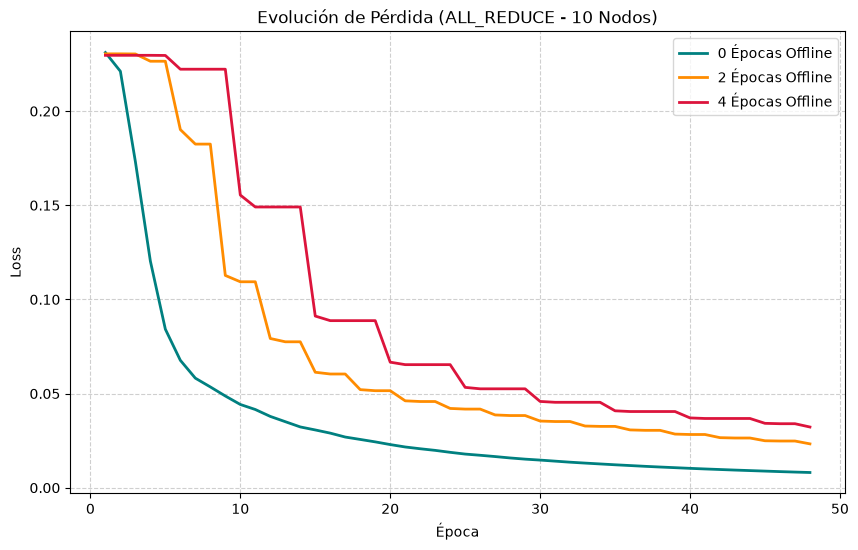

In [10]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))

# Isolating the control variables explicitly
control_alg = "all_reduce"
control_nodes = 10
colors = {0: "teal", 2: "darkorange", 4: "crimson"}

for oe in [0, 2, 4]:
    runs = list(measurements_if(algorithm=control_alg, nodes=control_nodes, offline_epochs=oe))
    if runs:
        ms = runs[0]
        epochs = list(range(1, len(ms.loss_history_avgs) + 1))
        
        plt.plot(
            epochs, 
            ms.loss_history_avgs, 
            label=f"{oe} Épocas Offline", 
            color=colors[oe], 
            linewidth=2
        )

plt.title(f"Evolución de Pérdida ({control_alg.upper()} - {control_nodes} Nodos)", fontsize=12)
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()